# Contexto

Um dos grandes indicadores acompanhados pelos investidores no mercado brasileiro é a taxa Selic. Esta taxa é a definição dos juros no Brasil, definida a cada 45 dias nas reuniões periódicas do COPOM.

Os segmentos dos investimentos reagem de formas diferentes ao cenário dos juros: alguns se beneficiam da alta enquanto outros sofrem, e o inverso é válido.

A proposta deste estudo é verificar o comportamento dos setores bancário e de varejo que, em tese, possuem reações opostas aos movimentos da taxa de juros.

Os bancos se beneficiam com o aumento dos juros, pois os juros cobrados aumentam, por exemplo, e no varejo o consumo diminuem pois os consumidores ficam mais conservadores pela alta dos preços.

## Introdução


In [1]:
!pip install yfinance matplotlib scikit-learn torch --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Coletando múltiplos ativos e extraindo indicadores técnicos


In [3]:
# Função com pandas puro para calcular indicadores
def add_indicators(df, col='Close', window=14):
    df[f'SMA_{window}'] = df[col].rolling(window=window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100 / (1 + rs))
    return df

#### Coleta-se os dados de dois ativos de cada setor, para comparação

Foram utilizados todos os ativos com terminação 3, apesar de os ativos de referencia para os bancos sejam o 4 para o Itaú e o 11 para o Santander.
A ideia é que utilizando a terminação 3 para os bancos, o comportamento dos ativos seja mais semelhante aos do varejo pelas carácterísticas do ativo, em questões além do preço.

In [4]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import yfinance as yf

# Coleta e preparação dos dados com indicadores
# tickers = ['MGLU3.SA', 'LREN3.SA', 'BBDC4.SA', 'ITUB4.SA']
# tickers = ['MGLU3.SA', 'LREN3.SA']
# tickers = ['BBDC4.SA', 'ITUB4.SA']
# tickers = ['MGLU3.SA', 'ITUB3.SA']
tickers = ['MGLU3.SA', 'LREN3.SA', 'ITUB3.SA', 'SANB3.SA']

# AMER3.SA, CEAB3.SA , BHIA3.SA, BBDC3.SA

dfs = []

for t in tickers:
    stock_df = yf.download(t, start='2019-01-01', end='2026-02-28')
    stock_df = stock_df[['Close']].rename(columns={'Close': f'{t}_Close'})
    stock_df = add_indicators(stock_df, col=f'{t}_Close', window=14)
    dfs.append(stock_df)

data = pd.concat(dfs, axis=1).dropna()

data.tail()

/tmp/ipykernel_78589/629813560.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(t, start='2019-01-01', end='2026-02-28')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_78589/629813560.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(t, start='2019-01-01', end='2026-02-28')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_78589/629813560.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(t, start='2019-01-01', end='2026-02-28')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_78589/629813560.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(t, start='2019-01-01', end='2026-02-28')
[*********************100%***********************]  1 of 1 comple

Price,MGLU3.SA_Close,SMA_14,EMA_14,RSI_14,LREN3.SA_Close,SMA_14,EMA_14,RSI_14,ITUB3.SA_Close,SMA_14,EMA_14,RSI_14,SANB3.SA_Close,SMA_14,EMA_14,RSI_14
Ticker,MGLU3.SA,,,,LREN3.SA,,,,ITUB3.SA,,,,SANB3.SA,,,
Date,,,,,,,,,,,,,,,,
2026-02-23,10.37,10.329286,10.276954,55.776889,15.309433,15.136214,15.079174,60.948891,43.809959,43.771724,43.630317,59.993639,17.400000,17.584286,17.559109,45.949915
2026-02-24,10.13,10.350714,10.257360,52.873564,15.654462,15.194658,15.155879,63.973045,44.513691,43.926065,43.748100,59.646032,17.780001,17.563571,17.588561,47.943269
2026-02-25,9.49,10.305714,10.155045,44.344705,15.555882,15.208036,15.209213,53.754919,43.988369,44.032262,43.780136,56.421233,17.260000,17.530000,17.544753,46.749658
2026-02-26,9.58,10.295000,10.078373,48.576854,15.822046,15.267888,15.290924,67.634816,44.146954,44.242533,43.829045,64.102573,16.900000,17.511429,17.458786,48.148146
2026-02-27,9.35,10.273571,9.981256,47.232480,15.358723,15.294646,15.299964,56.597223,43.195427,44.318287,43.744563,55.071115,16.500000,17.476429,17.330948,46.620690


#### Analise de correlação dos fechamentos, para verificar se possuem tendências convergentes ou divergentes

OBS: muitos ativos foram testados tanto aqui quanto na seção de visualização dos dados normalizados. Por fim restaram os que estão sendo usados no notebook.

Alguns ativos possuiam correlação muito positiva com o setor oposto, outros não possuiam variação nem preço significantes para que o modelo aprendesse algum padrão, e as predições ficavam irreais etc.

AMER3 e BHIA3 eram mais estáveis e com preço baixo.
CEAB4 e BBDC4 tinham muita correlação positiva com o varejo.

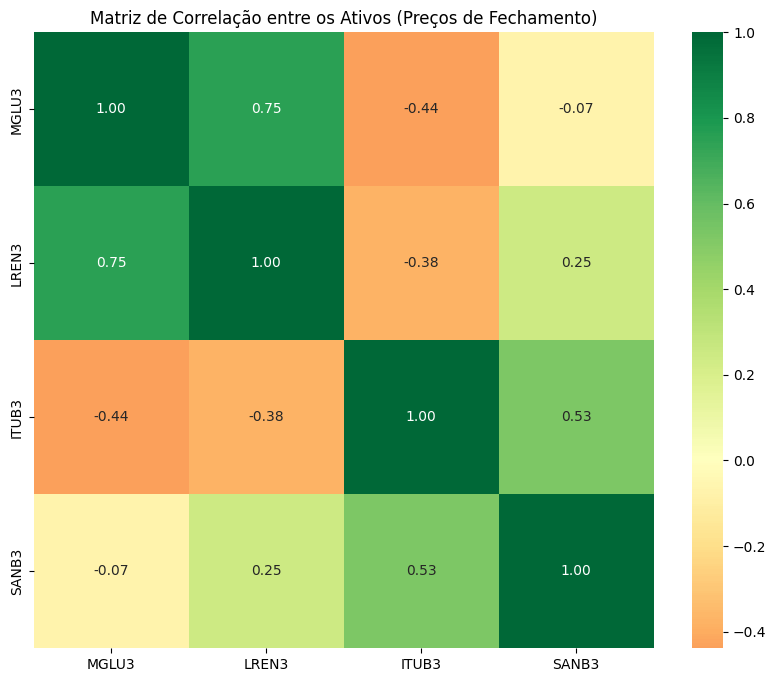

,MGLU3,LREN3,ITUB3,SANB3
MGLU3,1.000000,0.749618,-0.439023,-0.074943
LREN3,0.749618,1.000000,-0.377944,0.245404
ITUB3,-0.439023,-0.377944,1.000000,0.526992
SANB3,-0.074943,0.245404,0.526992,1.000000


In [5]:
import seaborn as sns

# Filtrar apenas as colunas de fechamento para os ativos
close_cols = [col for col in data.columns if '_Close' in col[0]]
df_corr = data[close_cols].copy()

# Renomear colunas para facilitar a leitura no gráfico
df_corr.columns = [col[0].replace('.SA_Close', '') for col in df_corr.columns]

# Calcular a matriz de correlação
correlation_matrix = df_corr.corr()

# Plotar o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Matriz de Correlação entre os Ativos (Preços de Fechamento)')
plt.show()

display(correlation_matrix)

In [6]:
# Normalizando os dados multivariados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [7]:
def create_multivariate_sequences(data, seq_len, target_indices):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        # Coleta o fechamento de todos os ativos (alvos múltiplos)
        y.append(data[i, target_indices])
    return np.array(X), np.array(y)

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

#### Definida janela de 45 dias pois é o periodo de decisão e possível alteração da taxa de juros pelo COPOM.

Testes foram realizados com a janela de 3 meses e de uma semana, e em ambas a conformidade dos dados reais com as previsões se mostrou muito inferior em relação à janela de 45 dias.

In [9]:
seq_len = 45
target_indices = [i for i, col in enumerate(data.columns) if '_Close' in col[0]]

X, y = create_multivariate_sequences(scaled, seq_len, target_indices)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

## Coleta e pré-processamento dos dados

## Dataset e DataLoader

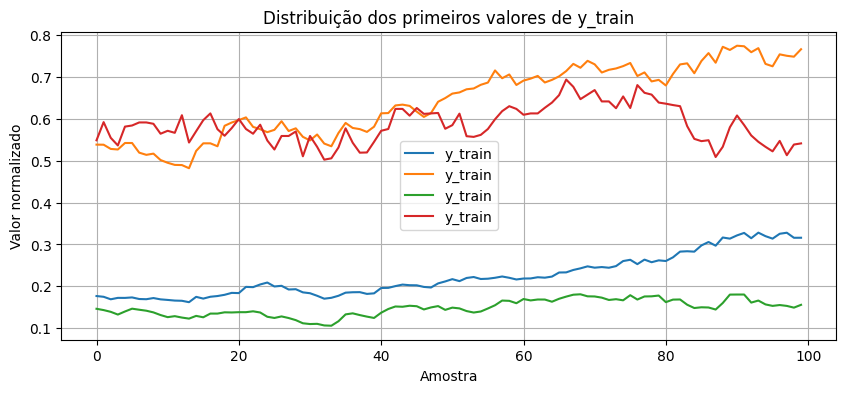

In [10]:
# 🔍 Verificar se y_train tem variação significativa
plt.figure(figsize=(10, 4))
plt.plot(y_train[:100], label='y_train')
plt.title('Distribuição dos primeiros valores de y_train')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

## Definindo o modelo LSTM com GRU

Definida a rede de forma a treinar com os dados de todos os ativos

In [11]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, output_size, hidden_lstm=64, hidden_gru=32):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm, batch_first=True)
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru, batch_first=True)
        # A saída agora corresponde ao número de ativos (output_size)
        self.fc = nn.Linear(hidden_gru, output_size)

    def forward(self, x):
        out_lstm, _ = self.lstm1(x)
        out_gru, _ = self.gru(out_lstm)
        # Saída baseada no último time step para todos os ativos alvo
        final_output = self.fc(out_gru[:, -1, :])
        return final_output

In [12]:
input_size = X_train.shape[2]
output_size = len(target_indices)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTM_GRU_Model(input_size=input_size, output_size=output_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Treinamento do modelo

Epoch 10: Train Loss = 0.000750, Val Loss = 0.004441
Epoch 20: Train Loss = 0.000657, Val Loss = 0.004188
Epoch 30: Train Loss = 0.000526, Val Loss = 0.002286
Epoch 40: Train Loss = 0.000491, Val Loss = 0.002642
Epoch 50: Train Loss = 0.000592, Val Loss = 0.002462


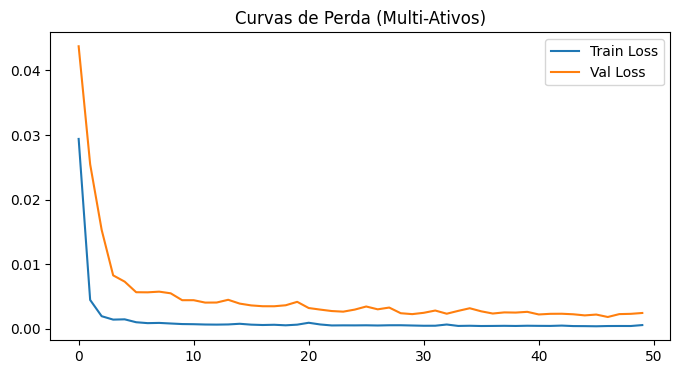

In [13]:
from copy import deepcopy
best_val_loss = float('inf')
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(1, 51):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())
    val_loss = np.mean(val_batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:2d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de Perda (Multi-Ativos)')
plt.legend()
plt.show()

#### Observando os resultados, nota-se um comportamento estranho

Analisando as predições abaixo, MGLU teve uma adequação baixa nas predições, talvez porque na pandemia seu valor era exorbitante (por volta de 200 reais) e agora é pequeno (8 reais). Seu gráfico de predições oscila bastante, fazendo movimentações de preço em saltos.

Os outros ativos tiveram boa predição.

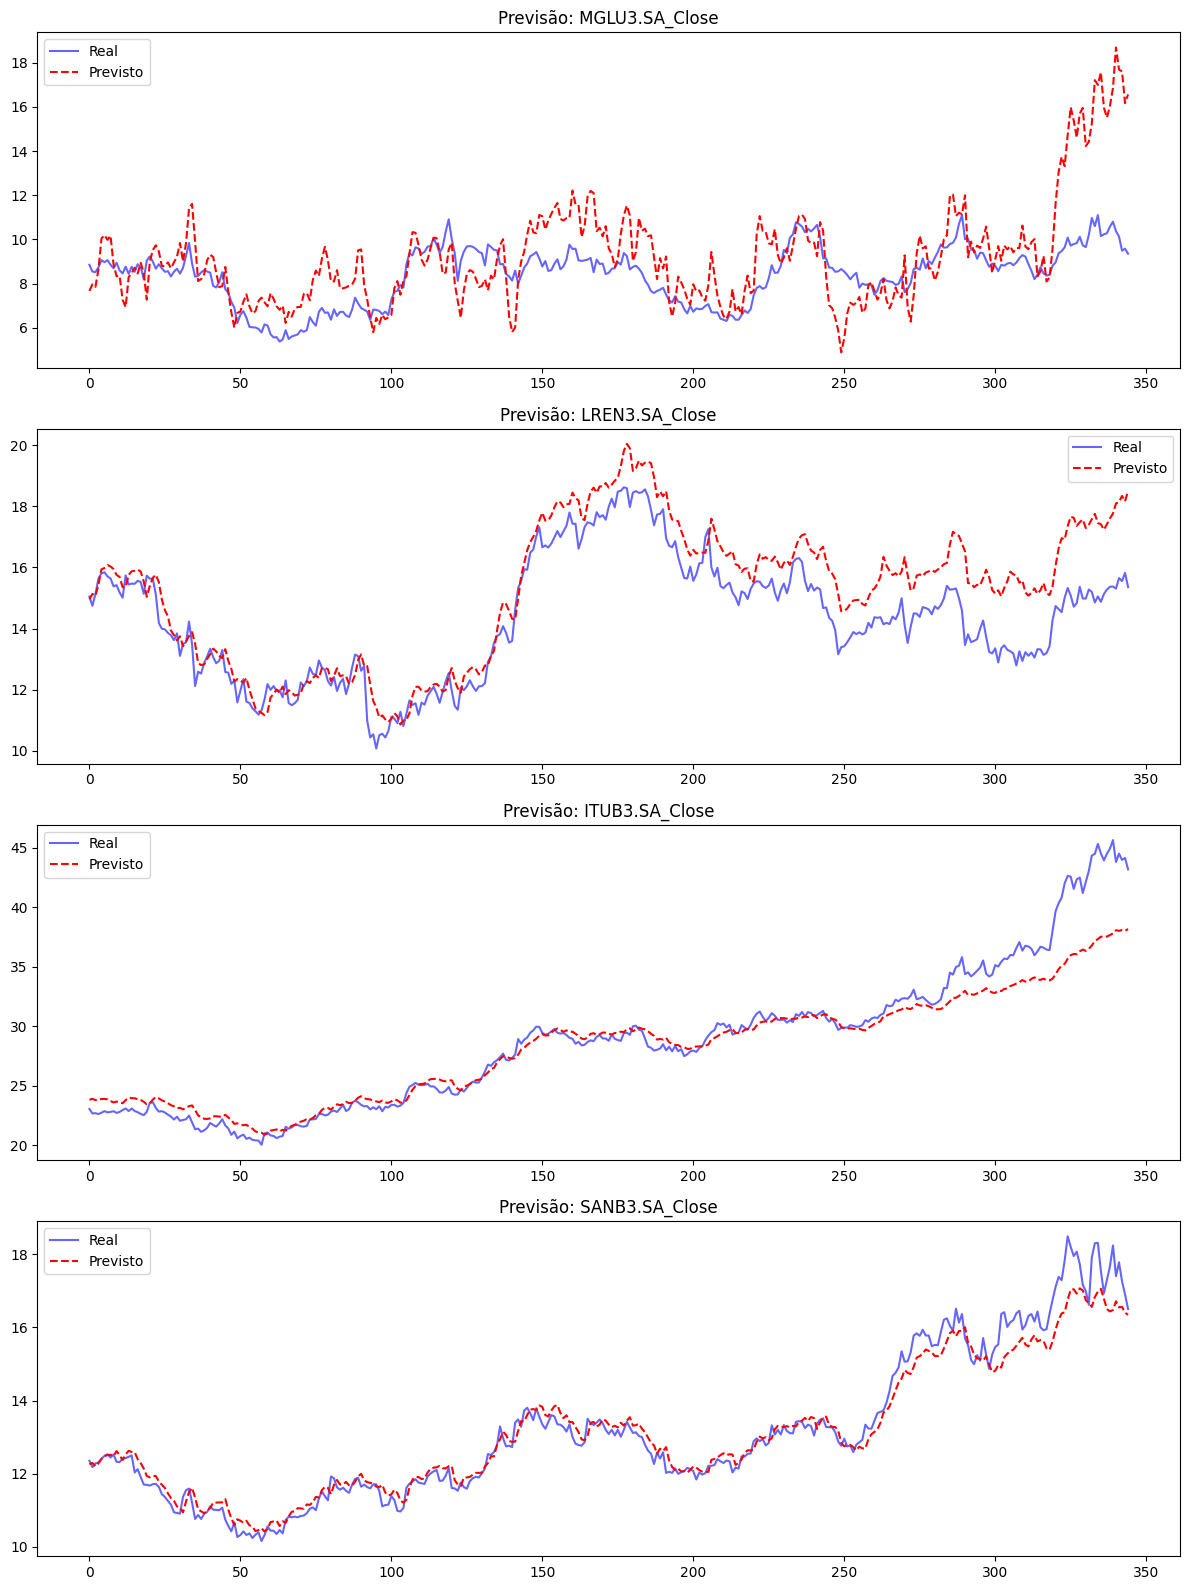

In [14]:
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

preds = np.array(preds)
fig, axes = plt.subplots(len(target_indices), 1, figsize=(12, 4 * len(target_indices)))
if len(target_indices) == 1: axes = [axes]

for i, idx in enumerate(target_indices):
    ticker_name = data.columns[idx][0]
    p_full = np.zeros((len(preds), scaler.n_features_in_))
    a_full = np.zeros((len(y_test), scaler.n_features_in_))
    p_full[:, idx] = preds[:, i]
    a_full[:, idx] = y_test[:, i]
    p_inv = scaler.inverse_transform(p_full)[:, idx]
    a_inv = scaler.inverse_transform(a_full)[:, idx]

    axes[i].plot(a_inv, label='Real', color='blue', alpha=0.6)
    axes[i].plot(p_inv, label='Previsto', color='red', linestyle='--')
    axes[i].set_title(f'Previsão: {ticker_name}')
    axes[i].legend()

plt.tight_layout()
plt.show()

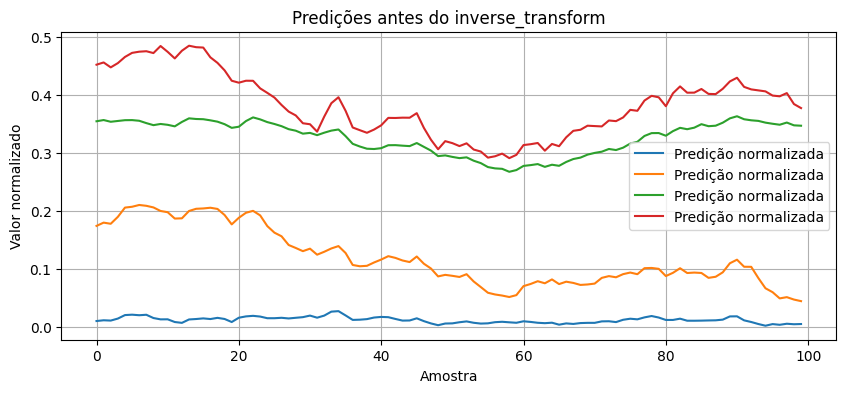

Predição (normalizada) - min: -0.0021, max: 0.8749, média: 0.3012


In [15]:
# 🧪 Diagnóstico: distribuição das predições normalizadas
plt.figure(figsize=(10, 4))
plt.plot(preds[:100], label='Predição normalizada')
plt.title('Predições antes do inverse_transform')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

print(f"Predição (normalizada) - min: {preds.min():.4f}, max: {preds.max():.4f}, média: {preds.mean():.4f}")

## Avaliação e visualização

/tmp/ipykernel_78589/3528370982.py:48: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


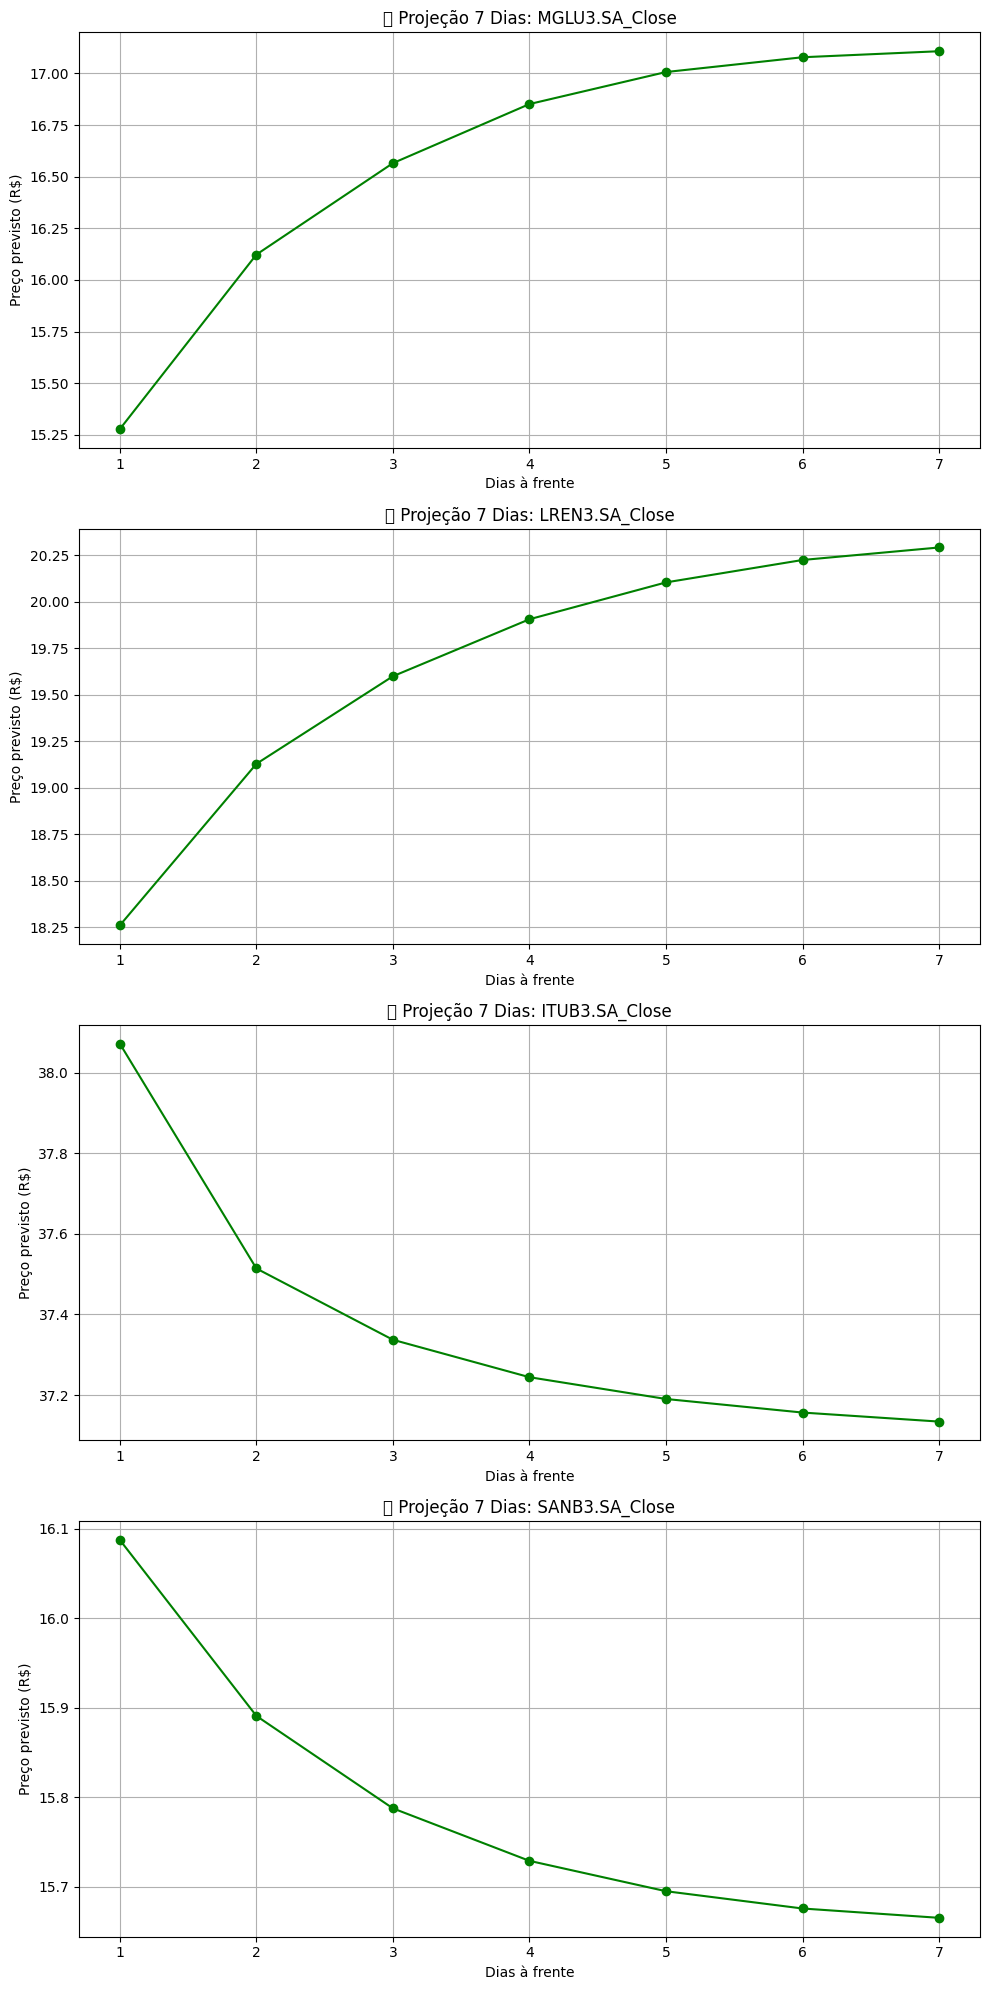

In [16]:
# 🧠 Previsão de múltiplos dias à frente para cada ativo
model.eval()
n_future = 7

# Identifica os nomes dos tickers
ticker_names = [data.columns[idx][0] for idx in target_indices]

fig, axes = plt.subplots(len(target_indices), 1, figsize=(10, 5 * len(target_indices)))
if len(target_indices) == 1: axes = [axes]

for i, target_idx in enumerate(target_indices):
    # Última sequência disponível global
    last_sequence = data[-seq_len:].values
    last_scaled = scaler.transform(last_sequence)
    current_input = torch.tensor(last_scaled, dtype=torch.float32).unsqueeze(0).to(device)

    future_preds = []
    for _ in range(n_future):
        with torch.no_grad():
            next_pred = model(current_input) # Retorna [1, output_size]
            pred_val = next_pred.cpu().numpy()[0, i] # Pega a predição específica do ativo i
            future_preds.append(pred_val)

        # Preparar próxima entrada
        next_step = current_input[0, -1, :].cpu().numpy()
        next_step[target_idx] = pred_val  # Atualiza apenas a coluna do ticker atual
        next_step = next_step.reshape(1, -1)

        # Deslocar janela temporal
        next_sequence = torch.cat([
            current_input[:, 1:, :],
            torch.tensor(next_step, dtype=torch.float32).unsqueeze(0).to(device)
        ], dim=1)
        current_input = next_sequence

    # Inverter normalização
    future_scaled_full = np.zeros((n_future, scaler.n_features_in_))
    future_scaled_full[:, target_idx] = future_preds
    future_prices = scaler.inverse_transform(future_scaled_full)[:, target_idx]

    # Plot individual
    axes[i].plot(range(1, n_future + 1), future_prices, marker='o', color='green')
    axes[i].set_title(f'📅 Projeção 7 Dias: {ticker_names[i]}')
    axes[i].set_xlabel('Dias à frente')
    axes[i].set_ylabel('Preço previsto (R$)')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Considerações finais

#### Era esperado que os gráficos fossem opostos em relação aos diferentes setores.

Os bancos possuem uma previsão futura de queda, enquanto o ativo LREN possui previsão de alta consistentemente, em reexecuções consecutivas do notebook, como esperado.

A questão cai sobre o ativo MGLU, cuja previsão às vezes é como o esperado mas outras vezes é igual aos bancos, conforme se repete o treinamento do modelo (execução do notebook).

Considerando o comentário já feito anteriormente, a respeito da performance das previsões deste ativo (MGLU), talvez não se deva considerar a previsão futura como válida, pois o comportamento aprendido pelo modelo não corresponde ao comportamento do ativo e não deve haver uma correlação correta com o restante dos ativos.
